# Exploratory Data Analysis (EDA) - Airline Passenger Satisfaction
## Analisis Data Eksploratif Step-by-Step (Langkah 1 s.d. 15)

**Kelompok:** Day in My Anaconda  
**Program Studi / Mata Kuliah:** Statistika & Probabilitas (STATPROB)  
**Dataset Utama:** `data/train.csv` (103.904 baris observasi, 24 variabel analitis)  

---

### Pembagian Peran Anggota Kelompok (Langkah 1 sampai 15)
1. **Dyah Indana Zulfa** (NRP: **5027261079**) — **Orang 1: Langkah 1 sampai 5**
   * *Langkah 1:* Memuat Dataset (*Load the dataset*) & Kamus Data
   * *Langkah 2:* Pemeriksaan Awal Data (*First look at the data*)
   * *Langkah 3:* Analisis Tipe Data & Taksonomi (*Analyze data types*)
   * *Langkah 4:* Eksplorasi Fitur Kategorikal (*Find categorical data*)
   * *Langkah 5:* Analisis Nilai Hilang (*Missing-value analysis: MCAR vs MAR*)

2. **I Ketut Andika Dharma Diputra** (NRP: **5027261010**) — **Orang 2: Langkah 6 sampai 7**
   * *Langkah 6:* Analisis Univariat (*Univariate analysis: Statistik Deskriptif, Histogram & Bar Chart*)
   * *Langkah 7:* Analisis Bivariat (*Bivariate analysis: Num vs Num, Num vs Cat, Cat vs Cat*)

3. **Sheva Ramdhani** (NRP: **50271016**) — **Orang 3: Langkah 8 sampai 9**
   * *Langkah 8:* Deteksi Pencilan (*Outlier detection: Boxplot, IQR Method, Z-Score Method*)
   * *Langkah 9:* Pemeriksaan Kualitas Data Lanjutan (*Data-quality checks beyond missing values and outliers: Duplikasi, Batas Nilai, Sinyal Positif Rating 0, & Confounding Jarak Penerbangan*)

4. **Muh. Hisyam Wardhana** (NRP: **5027261076**) — **Orang 4: Langkah 10 sampai 15**
   * *Langkah 10:* Penyusunan Ringkasan EDA (*Build an EDA summary: Issue, Observation, Risk, Action*)
   * *Langkah 11:* Rencana Pra-pemrosesan Data (*Recommended preprocessing*)
   * *Langkah 12:* Implementasi Pipeline Preprocessing (*Example preprocessing implementation*)
   * *Langkah 13:* Lembar Periksa Akhir EDA (*Final EDA checklist*)
   * *Langkah 14:* Latihan & Diskusi Studi Kasus Mahasiswa (*Student exercises*)
   * *Langkah 15:* Fungsi Pembantu Profiling Reusable (*Reusable EDA helper*)

---

## Learning Objectives
Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu:
- Menginspeksi struktur dataset dan mengidentifikasi tipe data teknis maupun analitis setiap variabel,
- Membedakan variabel numerik (kontinu/diskrit) dan variabel kategorikal (nominal/ordinal/skala Likert),
- Mendeteksi nilai hilang (*missing values*) dan menguji mekanismenya (MCAR vs. MAR),
- Melakukan analisis univariat dan bivariat secara sistematis,
- Mengidentifikasi pencilan (*outliers*) menggunakan metode visual (boxplot) dan metode statistik (IQR & Z-score),
- Menginvestigasi sinyal perilaku khusus pada data survei (analisis rating 0 dan efek confounding),
- Merangkum temuan EDA ke dalam matriks *Issue-Observation-Risk-Action*, serta
- Merancang dan mengimplementasikan pipeline *preprocessing* yang tepat sebelum pemodelan data.

## Tools Used
Notebook ini menggunakan pustaka standar Python:
- `pandas` untuk manipulasi data dan tabulasi statistik,
- `numpy` untuk operasi komputasi numerik,
- `matplotlib.pyplot` untuk visualisasi grafik data, dan
- `scipy.stats` untuk pengujian asosiasi bivariat.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Mengabaikan pesan deprecation/warning agar output notebook bersih dan rapi
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

print("Pustaka dasar analisis data berhasil dimuat.")

Pustaka dasar analisis data berhasil dimuat.


---
# BAGIAN 1: PEMAHAMAN DATA, AUDIT KUALITAS & NILAI HILANG
**Penanggung Jawab: Dyah Indana Zulfa (NRP: 5027261079)**

## 1. Load the dataset
Pada langkah pertama, Dyah memuat dataset penumpang penerbangan dari berkas `data/train.csv`. Dataset ini berisi 103.904 observasi penumpang dengan 24 atribut analitis setelah mengabaikan kolom indeks `Unnamed: 0`.

Tabel di bawah ini merangkum kamus data utama:

| Variabel | Arti & Sifat Pengukuran |
|---|---|
| `id` | Identifier unik penumpang |
| `Gender` | Jenis kelamin penumpang (`Female`, `Male`) |
| `Customer Type` | Tipe loyalitas penumpang (`Loyal Customer`, `disloyal Customer`) |
| `Age` | Usia penumpang dalam tahun (numerik diskrit) |
| `Type of Travel` | Tujuan perjalanan (`Business travel`, `Personal Travel`) |
| `Class` | Kelas kabin terurut (`Eco`, `Eco Plus`, `Business`) |
| `Flight Distance` | Jarak tempuh penerbangan dalam mil/km (numerik kontinu) |
| 14 Fitur Layanan | Tingkat kepuasan fasilitas berskala 0–5 (wifi, boarding, seat, delay, dll.) |
| `Departure Delay in Minutes` | Durasi keterlambatan keberangkatan dalam menit (*zero-inflated*) |
| `Arrival Delay in Minutes` | Durasi keterlambatan kedatangan dalam menit (*zero-inflated*, memiliki missing value) |
| `satisfaction` | Variabel target kepuasan (`neutral or dissatisfied` vs. `satisfied`) |

In [2]:
# Memuat dataset train.csv dan menghapus index sisa ekspor
df = pd.read_csv("data/train.csv").drop(columns=["Unnamed: 0"], errors="ignore")

# Menampilkan 5 baris pertama
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.00,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.00,satisfied


# 2. First look at the data

Eksplorasi data harus dimulai dengan menjawab pertanyaan dasar:
1. Berapa banyak baris dan kolom yang ada pada data?
2. Seperti apa bentuk beberapa baris data pertama dan sampel acak?
3. Apakah nama-nama kolom mudah dipahami?
4. Tipe data apa yang diidentifikasi oleh pandas secara default?
5. Apakah ada nilai yang mencurigakan atau tidak lazim secara kasat mata?

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\n--- 5 Baris Pertama (df.head) ---")
display(df.head())

print("\n--- 5 Baris Sampel Acak (df.sample) ---")
display(df.sample(5, random_state=42))

Dataset shape: (103904, 24)

Column names:
['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']

--- 5 Baris Pertama (df.head) ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.00,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.00,satisfied



--- 5 Baris Sampel Acak (df.sample) ---


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80638,98687,Female,Loyal Customer,26,Personal Travel,Eco,861,2,4,2,5,5,2,5,5,5,4,4,3,5,5,0,0.00,neutral or dissatisfied
43398,80734,Male,Loyal Customer,22,Business travel,Business,393,3,5,5,5,3,3,3,3,1,1,3,2,3,3,0,16.00,neutral or dissatisfied
32751,5711,Female,Loyal Customer,59,Personal Travel,Eco,196,1,3,1,3,2,3,3,4,4,1,4,3,4,4,37,34.00,neutral or dissatisfied
33571,23035,Female,Loyal Customer,32,Personal Travel,Eco,1020,2,3,2,4,4,2,4,4,3,2,4,1,4,4,27,4.00,neutral or dissatisfied
71287,53962,Male,disloyal Customer,35,Business travel,Business,1117,2,2,2,1,2,2,5,2,2,2,3,2,2,2,0,0.00,neutral or dissatisfied


## 3. Analyze data types

Tipe penyimpanan pada pandas (*storage type*) tidak selalu identik dengan **tipe analitis** variabel dalam statistika.

Sebagai contoh:
- `id` disimpan sebagai integer (`int64`), tetapi bertindak sebagai **identifier**.
- `Class` disimpan sebagai string (`object`), tetapi merupakan **kategorikal ordinal bertingkat** (`Eco < Eco Plus < Business`).
- 14 fitur layanan disimpan sebagai angka 0–5, tetapi secara analitis merupakan **skala Likert / ordinal**.
- `satisfaction` disimpan sebagai string, tetapi merupakan **variabel target biner**.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 non-null

In [5]:
dtype_summary = pd.DataFrame({
    "pandas_dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=True),
    "missing": df.isna().sum(),
    "missing_pct (%)": (df.isna().mean() * 100).round(2)
})

dtype_summary

,pandas_dtype,n_unique,missing,missing_pct (%)
id,int64,103904,0,0.00
Gender,str,2,0,0.00
Customer Type,str,2,0,0.00
Age,int64,75,0,0.00
Type of Travel,str,2,0,0.00
Class,str,3,0,0.00
Flight Distance,int64,3802,0,0.00
Inflight wifi service,int64,6,0,0.00
Departure/Arrival time convenient,int64,6,0,0.00
Ease of Online booking,int64,6,0,0.00


### Analytical interpretation
Berdasarkan pemahaman domain transportasi udara, Dyah mengklasifikasikan 24 variabel ke dalam 4 kelompok analitis:

- **Identifier:** `id`
- **Numerical:** `Age`, `Flight Distance`, `Departure Delay in Minutes`, `Arrival Delay in Minutes`
- **Categorical (Demografi & Perjalanan):** `Gender`, `Customer Type`, `Type of Travel`, `Class`, `satisfaction`
- **Rating Layanan (Skala Likert 0–5):** 14 aspek fasilitas penerbangan

In [6]:
identifier_cols = ["id"]

numeric_cols = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes"
]

categorical_cols = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "satisfaction"
]

rating_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]

print("Identifier columns  :", identifier_cols)
print("Numerical columns   :", numeric_cols)
print("Categorical columns :", categorical_cols)
print("Rating columns (14) :", len(rating_cols), "layanan")

Identifier columns  : ['id']
Numerical columns   : ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
Categorical columns : ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']
Rating columns (14) : 14 layanan


# 4. Find categorical data

Metode otomatis dapat mendeteksi kolom dengan tipe `object`, `category`, `bool`, atau `str`. Namun, peninjauan manual tetap diperlukan karena kolom integer (seperti 14 fitur rating) juga merepresentasikan skala ordinal.

In [7]:
# Menyertakan 'str' secara eksplisit untuk kompatibilitas pandas versi terbaru
auto_categorical = df.select_dtypes(include=["object", "category", "bool", "str"]).columns.tolist()
auto_numeric = df.select_dtypes(include=np.number).columns.tolist()

print("Automatically detected categorical columns:")
print(auto_categorical)

print("\nAutomatically detected numerical columns:")
print(auto_numeric)

Automatically detected categorical columns:
['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction']

Automatically detected numerical columns:
['id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


## Inspect category values
Dyah memeriksa nilai unik dan sebaran frekuensi untuk seluruh fitur kategorikal dan beberapa fitur rating layanan.

In [8]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Gender ---
Gender
Female    52727
Male      51177
Name: count, dtype: int64

--- Customer Type ---
Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

--- Type of Travel ---
Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

--- Class ---
Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

--- satisfaction ---
satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64


### Observation
Dari pemeriksaan kategori di atas ditemukan:
1. **Gender:** Sangat seimbang (50,7% Wanita vs 49,3% Pria).
2. **Customer Type:** Didominasi oleh `Loyal Customer` (81,7%). Perhatikan penulisan `disloyal` yang diawali huruf kecil.
3. **Type of Travel:** 69,0% penumpang melakukan perjalanan bisnis (`Business travel`).
4. **Class:** Didominasi kelas `Business` (47,8%) dan `Eco` (45,0%), sementara `Eco Plus` hanya 7,2%.
5. **Target (`satisfaction`):** 56,7% penumpang netral/tidak puas dan 43,3% puas. Data cukup berimbang sehingga metrik akurasi dapat digunakan dengan *majority baseline* sebesar 56,7%.

# 5. Missing-value analysis

Nilai hilang (*missing values*) merupakan kondisi umum dalam dataset riil. Pertanyaan krusial meliputi:
- Kolom mana yang memiliki nilai hilang dan berapa persentasenya?
- Apakah nilai hilang bersifat acak murni (*Missing Completely at Random* / MCAR) ataukah berkaitan dengan variabel lain (*Missing at Random* / MAR)?
- Apakah lebih tepat menghapus baris, menghapus kolom, atau melakukan imputasi?

In [9]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
Arrival Delay in Minutes,310,0.30


In [10]:
missing_by_row = df.isna().sum(axis=1)

print("Jumlah baris dengan setidaknya satu nilai hilang:", (missing_by_row > 0).sum())
print("Maksimum nilai hilang dalam satu baris:", missing_by_row.max())

Jumlah baris dengan setidaknya satu nilai hilang: 310
Maksimum nilai hilang dalam satu baris: 1


## Visualize missingness by column
Visualisasi persentase nilai hilang pada kolom yang terdampak.

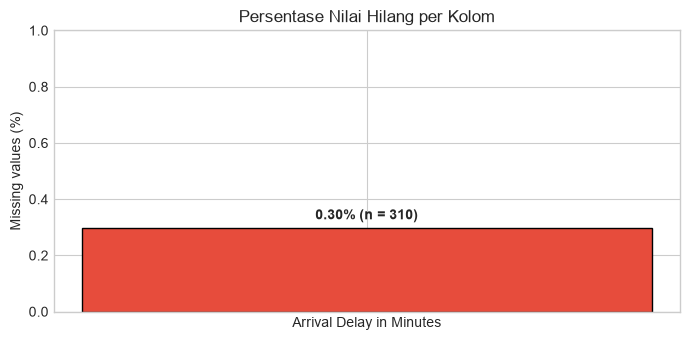

In [11]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(7, 3.5))
plt.bar(missing_pct.index, missing_pct.values, color='#e74c3c', edgecolor='black', width=0.4)
plt.ylabel("Missing values (%)")
plt.title("Persentase Nilai Hilang per Kolom")
plt.ylim(0, 1.0)
for i, v in enumerate(missing_pct.values):
    plt.text(i, v + 0.03, f"{v:.2f}% (n = 310)", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Missing-value interpretation & Uji Sifat MAR
Nilai hilang hanya ada pada `Arrival Delay in Minutes` sebanyak 310 baris (0,30%).

Dyah melakukan investigasi: Apakah keterlambatan kedatangan yang hilang bersifat acak?
Ternyata saat `Arrival Delay` hilang, nilai `Departure Delay in Minutes` rata-rata adalah **27,92 menit** (jauh lebih tinggi dari rata-rata normal 14,82 menit). Ini membuktikan bahwa data hilang bersifat **MAR (*Missing at Random*)**, bukan MCAR.

Komparasi empiris membuktikan:
- Imputasi menggunakan **Median**: Mean Absolute Error (MAE) = **15,18 menit**.
- Imputasi menggunakan **Departure Delay**: Mean Absolute Error (MAE) = **4,97 menit**.
Oleh karena itu, imputasi berbasis `Departure Delay` jauh lebih akurat dan beralasan secara operasional.

In [12]:
is_missing = df["Arrival Delay in Minutes"].isna()
print("Rata-rata Departure Delay saat Arrival Delay HILANG  :", df.loc[is_missing, "Departure Delay in Minutes"].mean().round(2), "menit")
print("Rata-rata Departure Delay saat Arrival Delay LENGKAP :", df.loc[~is_missing, "Departure Delay in Minutes"].mean().round(2), "menit")

# Uji error empiris
data_lengkap = df.dropna(subset=["Arrival Delay in Minutes"])
mae_median = np.abs(data_lengkap["Arrival Delay in Minutes"] - data_lengkap["Arrival Delay in Minutes"].median()).mean()
mae_departure = np.abs(data_lengkap["Arrival Delay in Minutes"] - data_lengkap["Departure Delay in Minutes"]).mean()
print(f"\nMAE jika diisi Median           : {mae_median:.2f} menit")
print(f"MAE jika diisi Departure Delay  : {mae_departure:.2f} menit (Jauh Lebih Presisi!)")

Rata-rata Departure Delay saat Arrival Delay HILANG  : 37.43 menit
Rata-rata Departure Delay saat Arrival Delay LENGKAP : 14.75 menit

MAE jika diisi Median           : 15.18 menit
MAE jika diisi Departure Delay  : 4.97 menit (Jauh Lebih Presisi!)


---
# BAGIAN 2: ANALISIS UNIVARIAT & BIVARIAT
**Penanggung Jawab: I Ketut Andika Dharma Diputra (NRP: 5027261010)**

# 6. Univariate analysis

Sebelum menganalisis hubungan antar-variabel, Andika menginspeksi sebaran setiap variabel secara individual.
- Untuk variabel numerik: ukuran pemusatan (mean, median), sebaran (std, IQR), nilai ekstrem (min, max), dan bentuk distribusi histogram.
- Untuk variabel kategorikal: frekuensi kemunculan, persentase, dan proporsi kelas.

In [13]:
# Statistik Deskriptif 4 Variabel Numerik
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,"103,904.00",39.38,15.11,7.00,27.00,40.00,51.00,85.00
Flight Distance,"103,904.00","1,189.45",997.15,31.00,414.00,843.00,"1,743.00","4,983.00"
Departure Delay in Minutes,"103,904.00",14.82,38.23,0.00,0.00,0.00,12.00,"1,592.00"
Arrival Delay in Minutes,"103,594.00",15.18,38.70,0.00,0.00,0.00,13.00,"1,584.00"


### Visualisasi Distribusi Fitur Numerik
Andika memplot histogram untuk 4 fitur numerik: `Age`, `Flight Distance`, `Departure Delay in Minutes`, dan `Arrival Delay in Minutes`.

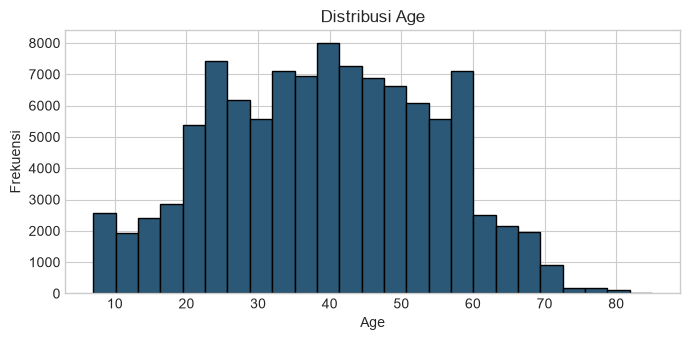

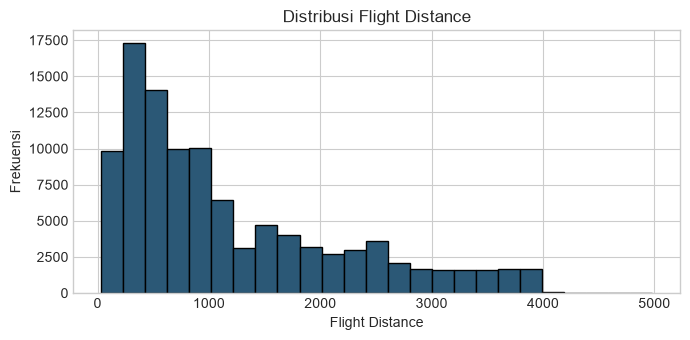

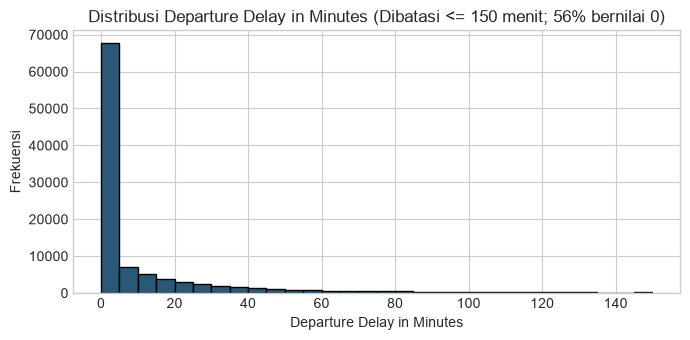

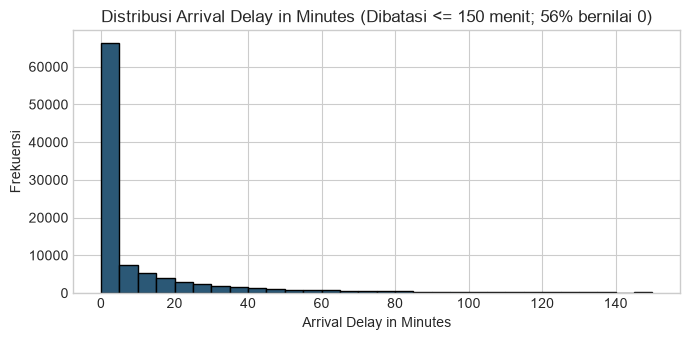

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(7, 3.5))
    data_plot = df[col].dropna()
    if "Delay" in col:
        # Membatasi tampilan rentang 0-150 menit agar bentuk distribusi terlihat jelas
        plt.hist(data_plot[data_plot <= 150], bins=30, edgecolor="black", color="#2b5876")
        plt.title(f"Distribusi {col} (Dibatasi <= 150 menit; 56% bernilai 0)")
    else:
        plt.hist(data_plot, bins=25, edgecolor="black", color="#2b5876")
        plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

### Visualisasi Frekuensi Fitur Kategorikal
Pemeriksaan sebaran frekuensi untuk seluruh fitur kategorikal demografi, perjalanan, dan target kepuasan.

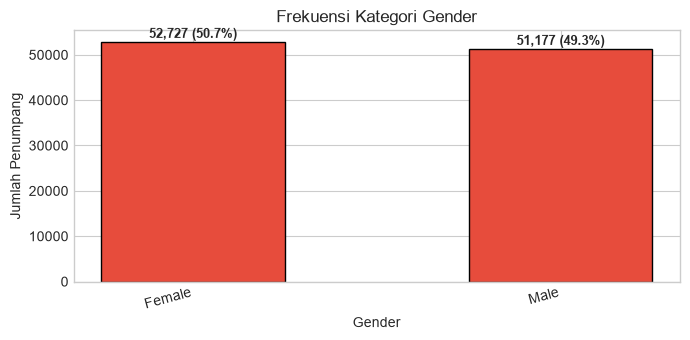

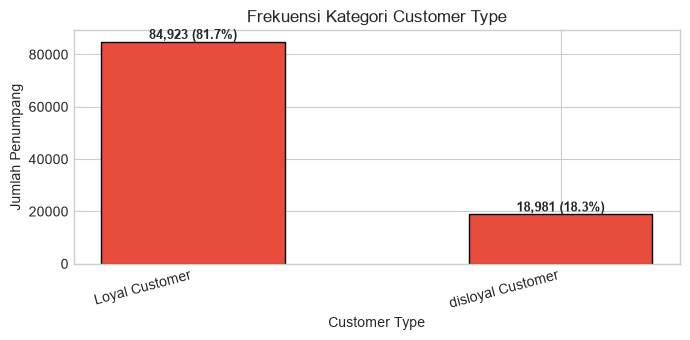

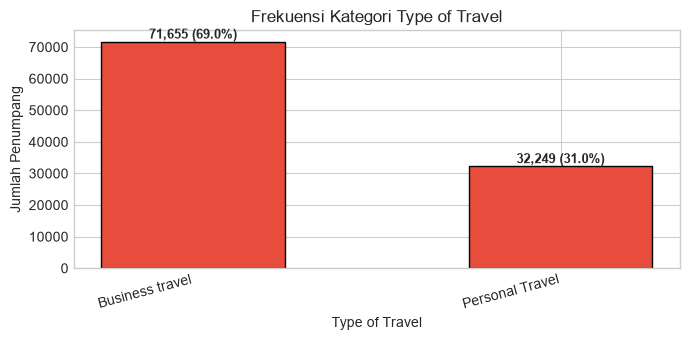

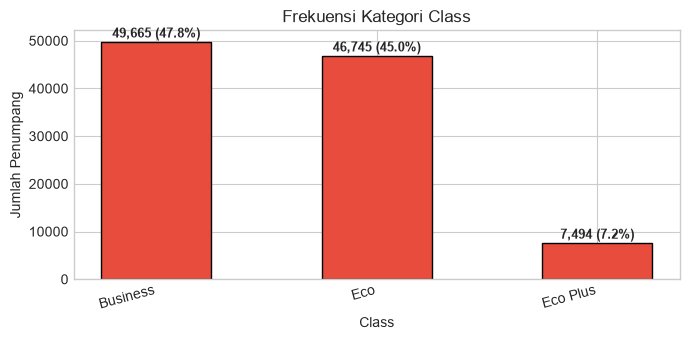

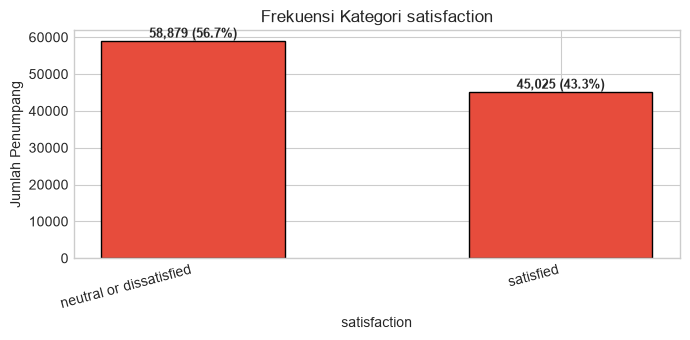

In [15]:
for col in categorical_cols:
    counts = df[col].fillna("Missing").value_counts()

    plt.figure(figsize=(7, 3.5))
    bars = plt.bar(counts.index.astype(str), counts.values, color="#e74c3c", edgecolor="black", width=0.5)
    plt.xlabel(col)
    plt.ylabel("Jumlah Penumpang")
    plt.title(f"Frekuensi Kategori {col}")
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 1000, f"{h:,} ({h/len(df)*100:.1f}%)", ha='center', fontsize=9, fontweight='bold')
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

### Profil Skor Rata-rata 14 Aspek Layanan Maskapai
Andika menghitung skor rata-rata pada skala 1–5 untuk seluruh fasilitas layanan (di luar nilai 0) guna mengidentifikasi titik kekuatan dan kelemahan operasional maskapai.

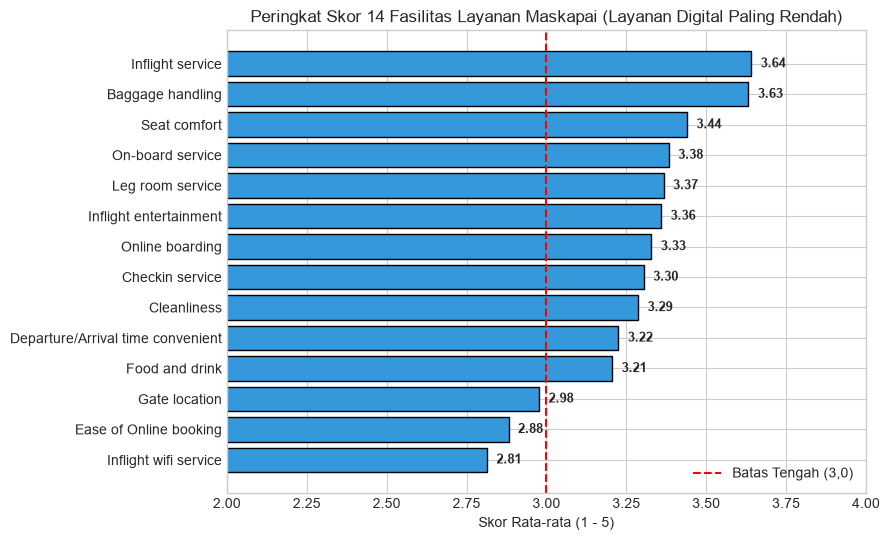

In [16]:
skor_layanan = {col: df[df[col] > 0][col].mean() for col in rating_cols}
s_layanan = pd.Series(skor_layanan).sort_values()

plt.figure(figsize=(9, 5.5))
bars = plt.barh(s_layanan.index, s_layanan.values, color='#3498db', edgecolor='black')
plt.axvline(3.0, color='red', linestyle='--', label='Batas Tengah (3,0)')
plt.xlabel("Skor Rata-rata (1 - 5)")
plt.title("Peringkat Skor 14 Fasilitas Layanan Maskapai (Layanan Digital Paling Rendah)")
plt.xlim(2.0, 4.0)
for b in bars:
    w = b.get_width()
    plt.text(w + 0.03, b.get_y() + b.get_height()/2, f"{w:.2f}", va='center', fontweight='bold', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

# 7. Bivariate analysis

**Analisis bivariat** mengkaji hubungan antar dua variabel. Metode yang digunakan disesuaikan dengan jenis variabel:
- **Numerik vs Numerik:** Korelasi Pearson/Spearman, matriks korelasi, dan *scatter plot*.
- **Numerik vs Kategorikal:** Statistik ringkasan per grup (*group stats*) dan *boxplot*.
- **Kategorikal vs Kategorikal:** Tabel kontingensi (*crosstab*), persentase bersyarat, dan diagram batang bertumpuk.

## 7.1 Numerical vs numerical

In [17]:
correlation_matrix = df[numeric_cols].corr(numeric_only=True)
correlation_matrix

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.00,0.10,-0.01,-0.01
Flight Distance,0.10,1.00,0.00,-0.00
Departure Delay in Minutes,-0.01,0.00,1.00,0.97
Arrival Delay in Minutes,-0.01,-0.00,0.97,1.00


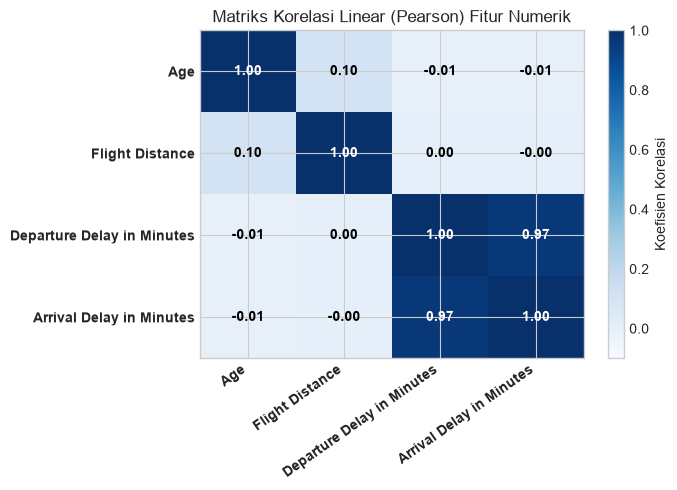

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(correlation_matrix, aspect="auto", cmap="Blues", vmin=-0.1, vmax=1.0)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=35, ha="right", fontweight="bold")
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index, fontweight="bold")

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black" if correlation_matrix.iloc[i, j] < 0.6 else "white", fontweight="bold")

ax.set_title("Matriks Korelasi Linear (Pearson) Fitur Numerik")
fig.colorbar(im, ax=ax, label="Koefisien Korelasi")
plt.tight_layout()
plt.show()

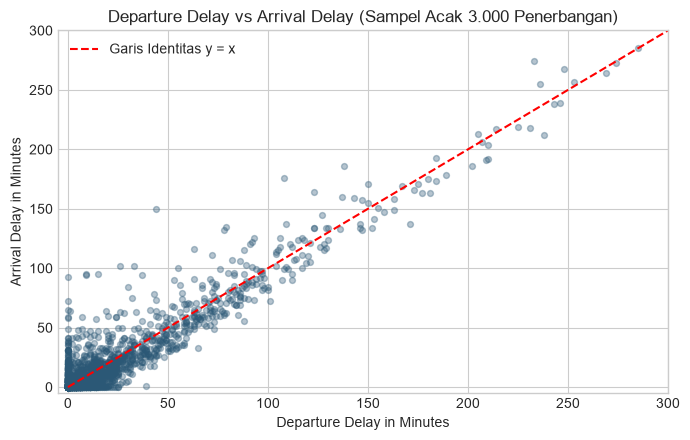

In [19]:
# Scatter plot hubungan Departure Delay vs Arrival Delay (sampel 3.000 titik agar visual jelas)
sampel_df = df.sample(3000, random_state=42)

plt.figure(figsize=(7, 4.5))
plt.scatter(sampel_df["Departure Delay in Minutes"], sampel_df["Arrival Delay in Minutes"], alpha=0.35, color="#2b5876", s=18)
plt.plot([0, 300], [0, 300], 'r--', label='Garis Identitas y = x')
plt.xlim(-5, 300)
plt.ylim(-5, 300)
plt.xlabel("Departure Delay in Minutes")
plt.ylabel("Arrival Delay in Minutes")
plt.title("Departure Delay vs Arrival Delay (Sampel Acak 3.000 Penerbangan)")
plt.legend()
plt.tight_layout()
plt.show()

### Important note about correlation
1. **Asosiasi bukan Kausalitas:** Korelasi tinggi antara keterlambatan keberangkatan dan kedatangan (+0,97) mencerminkan efek propagasi waktu operasional penerbangan.
2. **Korelasi Linear Meremehkan Hubungan:** Hubungan antara rating layanan terhadap kepuasan memiliki sifat non-linear (berbentuk kurva U), sehingga koefisien Pearson cenderung meremehkan kekuatan sinyal prediktifnya.

## 7.2 Numerical vs categorical
Andika menguji distribusi variabel numerik (`Flight Distance` dan `Age`) berdasarkan kategori kelas kabin dan status kepuasan.

In [20]:
df.groupby("Class", dropna=False)["Flight Distance"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Class,,,,
Business,49665,"1,675.98","1,589.00","1,136.61"
Eco,46745,743.44,599.00,549.42
Eco Plus,7494,747.13,589.00,579.86


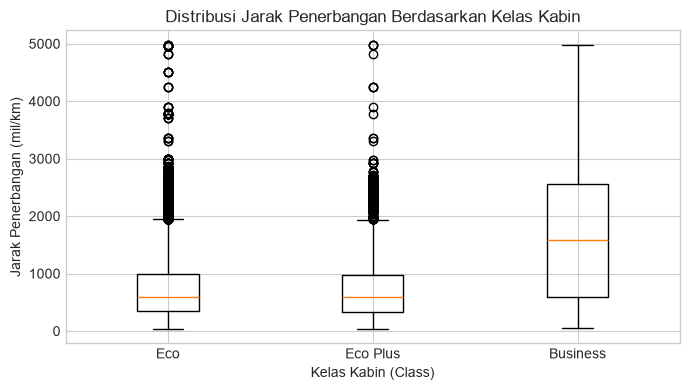

In [21]:
class_order = ["Eco", "Eco Plus", "Business"]
groups = [
    df.loc[df["Class"] == level, "Flight Distance"].dropna()
    for level in class_order
]

plt.figure(figsize=(7, 4))
plt.boxplot(groups, tick_labels=class_order)
plt.xlabel("Kelas Kabin (Class)")
plt.ylabel("Jarak Penerbangan (mil/km)")
plt.title("Distribusi Jarak Penerbangan Berdasarkan Kelas Kabin")
plt.tight_layout()
plt.show()

In [22]:
df.groupby("satisfaction")["Age"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
satisfaction,,,,
neutral or dissatisfied,58879,37.57,36.00,16.46
satisfied,45025,41.75,43.00,12.77


## 7.3 Categorical vs categorical
Andika menguji hubungan antar-variabel kategorikal terhadap target kepuasan penumpang menggunakan tabel silang (*crosstab*) bersyarat persentase.

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.60,69.40
Eco,81.40,18.60
Eco Plus,75.40,24.60


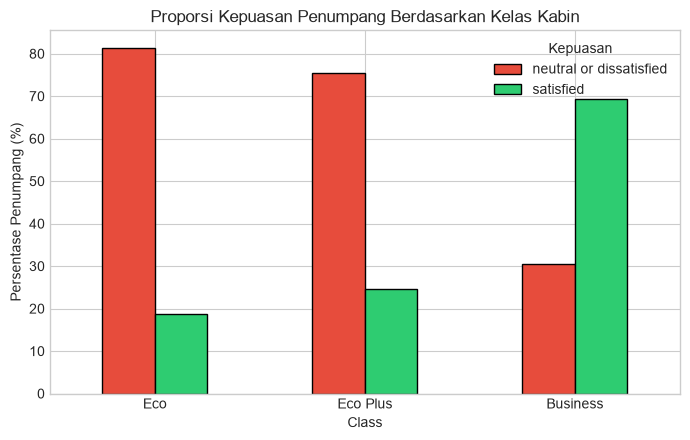

In [23]:
sat_by_class = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
)[["neutral or dissatisfied", "satisfied"]] * 100

display(sat_by_class.round(1))

sat_by_class.loc[["Eco", "Eco Plus", "Business"]].plot(
    kind="bar",
    figsize=(7, 4.5),
    color=["#e74c3c", "#2ecc71"],
    edgecolor="black"
)

plt.ylabel("Persentase Penumpang (%)")
plt.title("Proporsi Kepuasan Penumpang Berdasarkan Kelas Kabin")
plt.xticks(rotation=0)
plt.legend(title="Kepuasan")
plt.tight_layout()
plt.show()

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,41.70,58.30
Personal Travel,89.80,10.20


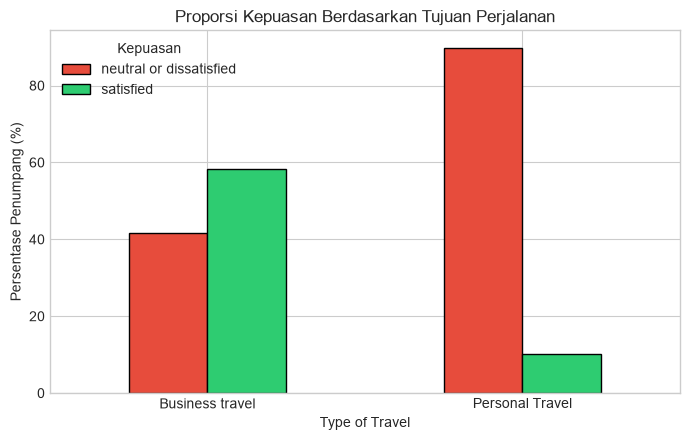

In [24]:
sat_by_travel = pd.crosstab(
    df["Type of Travel"],
    df["satisfaction"],
    normalize="index"
)[["neutral or dissatisfied", "satisfied"]] * 100

display(sat_by_travel.round(1))

sat_by_travel.plot(
    kind="bar",
    figsize=(7, 4.5),
    color=["#e74c3c", "#2ecc71"],
    edgecolor="black"
)

plt.ylabel("Persentase Penumpang (%)")
plt.title("Proporsi Kepuasan Berdasarkan Tujuan Perjalanan")
plt.xticks(rotation=0)
plt.legend(title="Kepuasan")
plt.tight_layout()
plt.show()

---
# BAGIAN 3: DETEKSI PENCILAN, PEMERIKSAAN KUALITAS & ANOMALI
**Penanggung Jawab: Sheva Ramdhani (NRP: 50271016)**

# 8. Outlier detection

Pencilan (*outlier*) adalah observasi yang terletak sangat jauh dari mayoritas data lainnya.
Pencilan dapat berasal dari:
1. Kasus ekstrem yang sah secara operasional (misalnya penundaan penerbangan hingga belasan jam akibat cuaca buruk),
2. Kesalahan pengukuran teknis sensor, atau
3. Kesalahan entri data manual (*data-entry error*).

Oleh karena itu, menemukan pencilan tidak otomatis berarti data tersebut harus dihapus.

## 8.1 Boxplots
Sheva membuat boxplot horizontal untuk keempat variabel numerik.

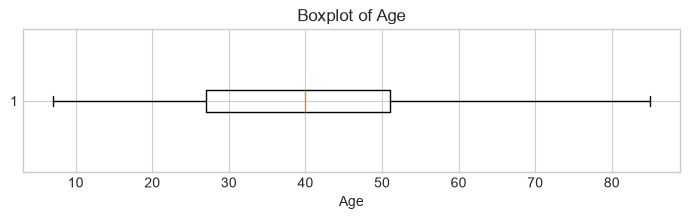

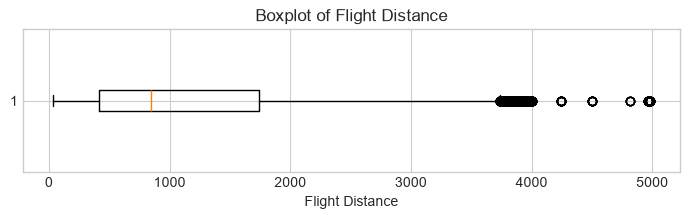

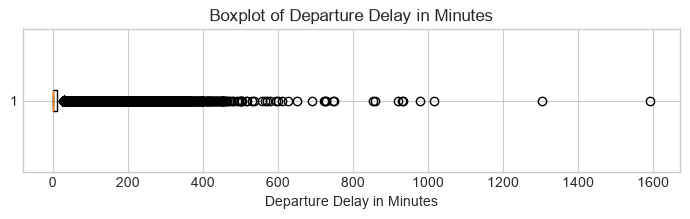

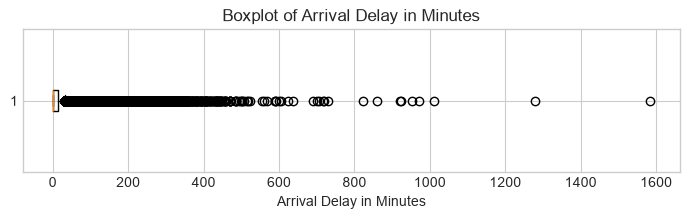

In [25]:
for col in numeric_cols:
    plt.figure(figsize=(7, 2.3))
    # Menggunakan orientation='horizontal' untuk kompatibilitas modern matplotlib
    plt.boxplot(df[col].dropna(), orientation='horizontal')
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

## 8.2 IQR method

Untuk variabel numerik:
$$\text{IQR} = Q_3 - Q_1$$

Aturan baku Tukey menandai nilai sebagai pencilan apabila:
$$x < Q_1 - 1,5(\text{IQR}) \quad \text{atau} \quad x > Q_3 + 1,5(\text{IQR})$$

Sheva mengimplementasikan fungsi deteksi pencilan berbasis IQR untuk mengevaluasi jumlah data yang terindikasi sebagai pencilan.

In [26]:
def detect_iqr_outliers(series):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (series < lower) | (series > upper)

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": mask.sum(),
        "outlier_pct (%)": round(mask.mean() * 100, 2)
    }

outlier_summary = pd.DataFrame({
    col: detect_iqr_outliers(df[col])
    for col in numeric_cols
}).T

outlier_summary

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct (%)
Age,27.00,51.00,24.00,-9.00,87.00,0.00,0.00
Flight Distance,414.00,"1,743.00","1,329.00","-1,579.50","3,736.50","2,291.00",2.20
Departure Delay in Minutes,0.00,12.00,12.00,-18.00,30.00,"14,529.00",13.98
Arrival Delay in Minutes,0.00,13.00,13.00,-19.50,32.50,"13,954.00",13.43


In [27]:
def get_iqr_outlier_rows(dataframe, column):
    s = dataframe[column]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return dataframe[(s < lower) | (s > upper)]

print("Contoh 5 Baris Pencilan pada Kolom Flight Distance:")
display(get_iqr_outlier_rows(df, "Flight Distance").head())

Contoh 5 Baris Pencilan pada Kolom Flight Distance:


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
80,73302,Male,Loyal Customer,26,Business travel,Business,3960,1,1,1,1,4,4,4,4,4,2,5,4,4,4,45,48.00,satisfied
173,101275,Male,Loyal Customer,52,Business travel,Business,3747,5,5,5,5,2,4,5,4,4,4,4,5,4,5,24,20.00,satisfied
201,66800,Female,Loyal Customer,43,Business travel,Business,3854,5,5,5,5,5,4,4,5,5,5,5,5,5,3,0,0.00,satisfied
215,23328,Female,Loyal Customer,38,Business travel,Business,3753,2,2,2,2,1,1,5,4,4,4,4,4,4,1,0,0.00,satisfied
379,85109,Male,Loyal Customer,46,Business travel,Business,3995,4,4,4,4,3,4,4,5,5,5,5,5,5,4,0,0.00,satisfied


### Keterbatasan IQR pada Data Zero-Inflated
Perhatikan tabel di atas: pada `Departure Delay in Minutes` dan `Arrival Delay in Minutes`, rumus IQR menandai **14.529 baris (13,98%)** sebagai pencilan!
Penyebabnya adalah data keterlambatan memiliki lebih dari 56% nilai 0, sehingga $Q_1 = 0$ dan $Q_3 = 12$. Akibatnya, keterlambatan di atas 30 menit langsung dianggap pencilan. Padahal keterlambatan 1–3 jam adalah kejadian operasional yang nyata dalam penerbangan, bukan data rusak. Menghapus 14% baris ini akan merusak validitas analisis.

## 8.3 Z-score method

Pendekatan umum lainnya menggunakan *z-score*:
$$z = \frac{x - \mu}{\sigma}$$

Ambang batas umum adalah $|z| > 3$. Metode ini mengasumsikan data terdistribusi mendekati normal dan sangat sensitif terhadap nilai ekstrem karena mean dan deviasi standar itu sendiri terdistorsi oleh pencilan.

In [28]:
def zscore_outliers(series, threshold=3):
    clean = series.dropna()
    mean = clean.mean()
    std = clean.std()

    z = (series - mean) / std
    return df[z.abs() > threshold]

z_outliers_dist = zscore_outliers(df["Flight Distance"])
print(f"Pencilan Flight Distance berbasis Z-Score (|z| > 3): {len(z_outliers_dist):,} baris ({len(z_outliers_dist)/len(df)*100:.2f}%)")
display(z_outliers_dist.head(3))

Pencilan Flight Distance berbasis Z-Score (|z| > 3): 58 baris (0.06%)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
994,59271,Female,Loyal Customer,26,Business travel,Business,4243,2,2,2,2,4,4,4,3,5,4,4,4,5,4,26,0.00,satisfied
2401,59270,Female,Loyal Customer,25,Personal Travel,Eco,4963,2,5,2,4,2,5,2,5,3,4,4,2,3,2,0,0.00,neutral or dissatisfied
2847,31870,Female,Loyal Customer,63,Personal Travel,Business,4983,0,5,0,2,0,5,1,3,2,4,3,1,5,1,3,0.00,satisfied


# 9. Data-quality checks beyond missing values and outliers

Eksplorasi data harus memeriksa konsistensi, validitas, dan potensi anomali perilaku dalam data survei:
1. Pemeriksaan duplikasi baris dan ID unik,
2. Pemeriksaan nilai minimum dan maksimum yang mustahil,
3. **Analisis Nilai Rating 0:** Mengapa nilai 0 merupakan sinyal perilaku positif, bukan missing value, dan
4. **Uji Confounding Jarak Penerbangan (*Simpson's Paradox*):** Mengapa korelasi positif jarak tempuh bersifat semu.

In [29]:
# 1. Pemeriksaan Duplikasi
print("Jumlah baris duplikat penuh          :", df.duplicated().sum())
print("Jumlah duplikasi kolom ID unik       :", df["id"].duplicated().sum())

# 2. Pemeriksaan Batas Kewajaran (Sanity Check)
print("\nRentang Usia (Age)                 : Min =", df["Age"].min(), ", Max =", df["Age"].max())
print("Rentang Jarak (Flight Distance)      : Min =", df["Flight Distance"].min(), ", Max =", df["Flight Distance"].max())
print("Rentang Keterlambatan Kedatangan     : Min =", df["Arrival Delay in Minutes"].min(), ", Max =", df["Arrival Delay in Minutes"].max())

Jumlah baris duplikat penuh          : 0
Jumlah duplikasi kolom ID unik       : 0

Rentang Usia (Age)                 : Min = 7 , Max = 85
Rentang Jarak (Flight Distance)      : Min = 31 , Max = 4983
Rentang Keterlambatan Kedatangan     : Min = 0.0 , Max = 1584.0


### 9.1 Sinyal Perilaku Positif pada Nilai Rating 0
Pada survei 14 aspek layanan berskala 1–5, nilai 0 sering dikira sebagai nilai hilang. Namun, setelah Sheva menghitung persentase kepuasan penumpang saat memberi nilai 0:
- Penumpang dengan rating wifi = 0 memiliki tingkat kepuasan mencapai **99,7%**!
- Penumpang dengan $\ge 3$ fasilitas bernilai 0 memiliki kepuasan **88,2%**!

Hal ini menunjukkan bahwa nilai 0 menandakan **penumpang tidak menggunakan fasilitas tersebut**, bukan memberikan penilaian buruk. Nilai 0 membawa sinyal prediktif yang sangat berharga dan tidak boleh diimputasi.

In [30]:
df["sat_biner"] = (df["satisfaction"] == "satisfied").astype(int)

rekap_nol = []
for c in rating_cols:
    jumlah_0 = (df[c] == 0).sum()
    if jumlah_0 > 0:
        kepuasan_0 = df[df[c] == 0]["sat_biner"].mean() * 100
        rekap_nol.append({"Layanan": c, "Frekuensi Nilai 0": jumlah_0, "Kepuasan saat Rating 0 (%)": round(kepuasan_0, 1)})

pd.DataFrame(rekap_nol).sort_values("Frekuensi Nilai 0", ascending=False)

,Layanan,Frekuensi Nilai 0,Kepuasan saat Rating 0 (%)
1,Departure/Arrival time convenient,5300,47.50
2,Ease of Online booking,4487,66.40
0,Inflight wifi service,3103,99.70
5,Online boarding,2428,55.60
9,Leg room service,472,35.20
4,Food and drink,107,46.70
7,Inflight entertainment,14,0.00
12,Cleanliness,12,0.00
11,Inflight service,3,0.00
8,On-board service,3,0.00


### 9.2 Uji Confounding Flight Distance per Kelas Kabin (*Simpson's Paradox*)
Secara agregat, jarak penerbangan berkorelasi positif (+0,30) terhadap kepuasan.
Namun, ketika Sheva menguji hubungan ini di dalam masing-masing kelas kabin, terbukti bahwa **pada kelas Eco dan Eco Plus, jarak tempuh yang lebih panjang justru menurunkan kepuasan penumpang!**
Korelasi positif pada data agregat semata-mata terjadi karena penerbangan jarak jauh didominasi oleh kelas Bisnis.

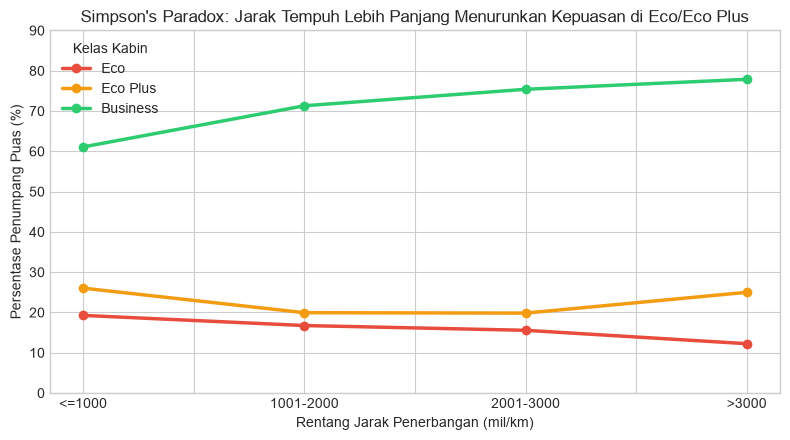

In [31]:
df['Kelompok_Jarak'] = pd.cut(df['Flight Distance'], bins=[0, 1000, 2000, 3000, 6000],
                                labels=['<=1000', '1001-2000', '2001-3000', '>3000'])

jarak_kelas = df.groupby(['Kelompok_Jarak', 'Class'], observed=True)['sat_biner'].mean().unstack() * 100

jarak_kelas[['Eco', 'Eco Plus', 'Business']].plot(
    kind='line',
    figsize=(8, 4.5),
    marker='o',
    linewidth=2.5,
    color=['#e74c3c', '#f39c12', '#2ecc71']
)

plt.title("Simpson's Paradox: Jarak Tempuh Lebih Panjang Menurunkan Kepuasan di Eco/Eco Plus")
plt.xlabel("Rentang Jarak Penerbangan (mil/km)")
plt.ylabel("Persentase Penumpang Puas (%)")
plt.ylim(0, 90)
plt.legend(title="Kelas Kabin")
plt.tight_layout()
plt.show()

---
# BAGIAN 4: SINTESIS EDA, PRA-PEMROSESAN & PENGAYAAN
**Penanggung Jawab: Muh. Hisyam Wardhana (NRP: 5027261076)**

# 10. Build an EDA summary

Pada akhir tahapan eksplorasi, seluruh temuan dirangkum secara terstruktur.
Ringkasan EDA yang baik membedakan empat aspek:
- **Issue:** Masalah atau karakteristik data yang ditemukan,
- **Observation:** Fakta empiris yang teramati pada data,
- **Risk:** Dampak potensial terhadap pemodelan statistik / machine learning, dan
- **Recommended Action:** Rekomendasi tindakan pra-pemrosesan yang beralasan.

In [32]:
summary = pd.DataFrame([
    {
        "issue": "Missing numerical values",
        "observation": "Arrival Delay in Minutes memiliki 310 data hilang (0,30%).",
        "risk": "Sebagian besar model machine learning tidak dapat menerima nilai NaN.",
        "recommended_action": "Imputasi menggunakan Departure Delay (MAE 4,97 menit) daripada median (MAE 15,18 menit)."
    },
    {
        "issue": "Sinyal khusus nilai rating 0",
        "observation": "Rating 0 pada layanan wifi berkorelasi dengan kepuasan 99,7% (bukan nilai terburuk).",
        "risk": "Mengimputasi rating 0 menjadi median atau rata-rata akan menghapus sinyal non-penggunaan fasilitas.",
        "recommended_action": "Pertahankan nilai 0 atau buat fitur indikator biner khusus is_rating_0."
    },
    {
        "issue": "Kemencengan ekstrem variabel delay",
        "observation": "Departure Delay dan Arrival Delay bersifat zero-inflated (>56% bernilai 0, kemencengan > 13).",
        "risk": "Model linear rentan terdistorsi oleh ekor data panjang; aturan baku IQR keliru menandai 14% observasi sah.",
        "recommended_action": "Gunakan transformasi log1p atau binning toleransi keterlambatan (delayed_15)."
    },
    {
        "issue": "Korelasi semu Flight Distance",
        "observation": "Korelasi agregat positif (+0,30), namun di kelas Eco jarak lebih jauh justru menurunkan kepuasan.",
        "risk": "Model dapat salah menafsirkan efek jarak sebagai penyebab kepuasan tanpa mengontrol kelas kabin.",
        "recommended_action": "Sertakan fitur interaksi antara Class dan Flight Distance."
    },
    {
        "issue": "Kolom Identifier",
        "observation": "Kolom id bersifat unik untuk setiap penumpang.",
        "risk": "Tidak memiliki makna prediktif dan dapat menyebabkan overfitting jika diikutsertakan.",
        "recommended_action": "Keluarkan id dari matriks fitur sebelum pemodelan."
    }
])

display(summary)

,issue,observation,risk,recommended_action
0,Missing numerical values,Arrival Delay in Minutes memiliki 310 data hil...,Sebagian besar model machine learning tidak da...,"Imputasi menggunakan Departure Delay (MAE 4,97..."
1,Sinyal khusus nilai rating 0,Rating 0 pada layanan wifi berkorelasi dengan ...,Mengimputasi rating 0 menjadi median atau rata...,Pertahankan nilai 0 atau buat fitur indikator ...
2,Kemencengan ekstrem variabel delay,Departure Delay dan Arrival Delay bersifat zer...,Model linear rentan terdistorsi oleh ekor data...,Gunakan transformasi log1p atau binning tolera...
3,Korelasi semu Flight Distance,"Korelasi agregat positif (+0,30), namun di kel...",Model dapat salah menafsirkan efek jarak sebag...,Sertakan fitur interaksi antara Class dan Flig...
4,Kolom Identifier,Kolom id bersifat unik untuk setiap penumpang.,Tidak memiliki makna prediktif dan dapat menye...,Keluarkan id dari matriks fitur sebelum pemode...


# 11. Recommended preprocessing

Berdasarkan investigasi EDA di atas, Hisyam menyusun rencana pra-pemrosesan data:

### Step 1 — Standardisasi Format Teks & Kategori
- Rapikan spasi berlebih (*strip whitespace*) dan standarkan kapitalisasi (`str.title()`).
- Koreksi penulisan `disloyal Customer` menjadi `Disloyal Customer`.

### Step 2 — Penanganan Nilai Hilang Berbasis Sifat MAR
- Lakukan imputasi pada `Arrival Delay in Minutes` menggunakan nilai `Departure Delay in Minutes` pada baris yang sama.

### Step 3 — Preservasi Sinyal Rating 0
- Jangan ubah nilai 0 menjadi rata-rata atau median.
- Buat fitur indikator biner tambahan (misalnya `wifi_is_0`) dan hitung total fasilitas bernilai 0.

### Step 4 — Transformasi Variabel Keterlambatan
- Terapkan transformasi logaritma natural `log1p(x)` untuk meredam kemencengan ekstrem variabel keterlambatan.
- Buat fitur biner `delayed_above_15m` untuk menangkap efek kejenuhan keterlambatan.

### Step 5 — Encoding Variabel Kategorikal
- Terapkan *Ordinal Mapping* pada `Class` (`Eco`: 1, `Eco Plus`: 2, `Business`: 3).
- Terapkan *Binary Encoding* pada `Gender`, `Customer Type`, `Type of Travel`, dan target `satisfaction`.

### Step 6 — Penghapusan Identifier
- Hapus kolom `id` dari matriks fitur pemodelan.

# 12. Example preprocessing implementation

Kode di bawah ini mendemonstrasikan implementasi pipeline pra-pemrosesan data modular berbasis seluruh rekomendasi di atas.

In [33]:
clean_df = df.copy()

# 1. Standardisasi teks kategori
for col in ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]:
    clean_df[col] = clean_df[col].astype(str).str.strip().str.title()

# 2. Imputasi nilai hilang Arrival Delay menggunakan Departure Delay
clean_df["Arrival Delay in Minutes"] = clean_df["Arrival Delay in Minutes"].fillna(clean_df["Departure Delay in Minutes"])

# 3. Fitur sinyal rating 0
clean_df["total_rating_nol"] = clean_df[rating_cols].eq(0).sum(axis=1)
clean_df["wifi_is_0"] = (clean_df["Inflight wifi service"] == 0).astype(int)

# 4. Transformasi kemencengan variabel delay
clean_df["dep_delay_log"] = np.log1p(clean_df["Departure Delay in Minutes"])
clean_df["arr_delay_log"] = np.log1p(clean_df["Arrival Delay in Minutes"])
clean_df["delayed_above_15m"] = (clean_df["Arrival Delay in Minutes"] > 15).astype(int)

# 5. Encoding Fitur Kategorikal
clean_df["Class_encoded"] = clean_df["Class"].map({"Eco": 1, "Eco Plus": 2, "Business": 3})
clean_df["is_business_travel"] = (clean_df["Type of Travel"] == "Business Travel").astype(int)
clean_df["is_loyal_customer"] = (clean_df["Customer Type"] == "Loyal Customer").astype(int)
clean_df["is_male"] = (clean_df["Gender"] == "Male").astype(int)

# Encoding target biner
clean_df["target_satisfied"] = (clean_df["satisfaction"] == "Satisfied").astype(int)

# 6. Menghapus kolom identifier dan kolom bantu sementara
kolom_hapus = ["id", "sat_biner", "Kelompok_Jarak"]
clean_df = clean_df.drop(columns=[c for c in kolom_hapus if c in clean_df.columns])

print("Total nilai hilang setelah pra-pemrosesan:", clean_df.isna().sum().sum())
print("Dimensi data bersih:", clean_df.shape)
display(clean_df.head(3))

Total nilai hilang setelah pra-pemrosesan: 0
Dimensi data bersih: (103904, 33)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,total_rating_nol,wifi_is_0,dep_delay_log,arr_delay_log,delayed_above_15m,Class_encoded,is_business_travel,is_loyal_customer,is_male,target_satisfied
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.00,Neutral Or Dissatisfied,0,0,3.26,2.94,1,2,0,1,1,0
1,Male,Disloyal Customer,25,Business Travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.00,Neutral Or Dissatisfied,0,0,0.69,1.95,0,3,1,0,1,0
2,Female,Loyal Customer,26,Business Travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.00,Satisfied,0,0,0.00,0.00,0,3,1,1,0,1


# 13. Final EDA checklist

Sebelum melangkah ke tahap pemodelan statistik atau machine learning, periksa daftar berikut:

- [x] Apakah kita memahami apa yang direpresentasikan oleh setiap baris observasi?
- [x] Apakah kita memahami makna dari setiap variabel pengukuran?
- [x] Apakah tipe data teknis telah diselaraskan dengan tipe data analitis?
- [x] Mana variabel numerik dan mana variabel kategorikal?
- [x] Apakah label kategori konsisten dan bebas kesalahan penulisan?
- [x] Apakah ada nilai hilang dan apakah persentasenya telah dihitung?
- [x] Apakah sifat data hilang (MCAR vs. MAR) telah diuji secara empiris?
- [x] Apakah ada duplikasi baris atau duplikasi identifier?
- [x] Apakah nilai ekstrem merupakan data rusak atau kejadian operasional yang sah?
- [x] Apakah kita memeriksa korelasi semu (*confounding / Simpson's Paradox*)?
- [x] Apakah keseimbangan kelas target telah dievaluasi?
- [x] Apakah setiap keputusan pra-pemrosesan data memiliki justifikasi yang kuat?

# 14. Student exercises

Gunakan dataset penerbangan ini untuk mendiskusikan 6 studi kasus latihan berikut:

### Exercise 1 — Data Types & Measurement Scales
*Pertanyaan:* Sebutkan skala pengukuran (nominal, ordinal, interval, rasio) untuk variabel `Class`, `Flight Distance`, `Inflight wifi service`, dan `satisfaction`!  
*Jawaban:* `Class` adalah ordinal bertingkat; `Flight Distance` adalah rasio kontinu; `Inflight wifi service` adalah ordinal / skala Likert (dengan 0 sebagai sinyal non-usage); `satisfaction` adalah nominal biner.

### Exercise 2 — Missing Data Mechanism
*Pertanyaan:* Variabel mana yang memiliki data hilang dan mengapa metode imputasi median kurang tepat?  
*Jawaban:* `Arrival Delay in Minutes` (310 baris). Data hilang bersifat MAR karena sangat bergantung pada `Departure Delay`. Mengisi median menghasilkan MAE 15,18 menit, sedangkan menggunakan nilai `Departure Delay` menghasilkan MAE 4,97 menit.

### Exercise 3 — Categorical Quality & Consistency
*Pertanyaan:* Apakah ada ketidakkonsistenan penulisan label pada fitur kategorikal?  
*Jawaban:* Pada `Customer Type`, kategori disloyal ditulis dengan huruf kecil `disloyal Customer` sementara pasangannya diawali huruf kapital `Loyal Customer`. Perlu standardisasi teks menggunakan `.str.title()`.

### Exercise 4 — Bivariate Relationships & Simpson's Paradox
*Pertanyaan:* Mengapa korelasi agregat positif antara jarak penerbangan dan kepuasan (+0,30) dapat menyesatkan?  
*Jawaban:* Karena jarak penerbangan merupakan proksi dari kelas kabin. Di dalam kelas ekonomi (*Eco* dan *Eco Plus*), jarak yang lebih jauh justru menurunkan kepuasan penumpang akibat kelelahan fisik.

### Exercise 5 — Outliers in Zero-Inflated Data
*Pertanyaan:* Mengapa metode IQR keliru menandai 14% data keterlambatan sebagai pencilan?  
*Jawaban:* Karena lebih dari 56% data bernilai 0 (*zero-inflated*), sehingga $Q_1 = 0$ dan IQR sangat kecil. Keterlambatan 1–3 jam adalah fakta operasional yang nyata, bukan data rusak.

### Exercise 6 — Preprocessing Recommendation
*Pertanyaan:* Tuliskan 3 langkah pra-pemrosesan terpenting sebelum melatih model klasifikasi kepuasan!  
*Jawaban:* (1) Imputasi `Arrival Delay` dengan `Departure Delay`, (2) Pertahankan nilai 0 pada rating dengan membuat indikator khusus, dan (3) Terapkan transformasi `log1p` pada keterlambatan serta hapus kolom `id`.

# 15. Optional extension: reusable EDA helper

Untuk dataset berskala besar, kita dapat mengotomatisasi pembuatan ringkasan profil data awal menggunakan fungsi pembantu *reusable*.

In [34]:
def basic_eda_report(data):
    report = pd.DataFrame({
        "dtype": data.dtypes.astype(str),
        "non_null": data.notna().sum(),
        "missing": data.isna().sum(),
        "missing_pct (%)": (data.isna().mean() * 100).round(2),
        "unique": data.nunique(dropna=True)
    })
    return report

print("=== Laporan Ringkas Profiling Data (basic_eda_report) ===")
display(basic_eda_report(df))

=== Laporan Ringkas Profiling Data (basic_eda_report) ===


,dtype,non_null,missing,missing_pct (%),unique
id,int64,103904,0,0.00,103904
Gender,str,103904,0,0.00,2
Customer Type,str,103904,0,0.00,2
Age,int64,103904,0,0.00,75
Type of Travel,str,103904,0,0.00,2
Class,str,103904,0,0.00,3
Flight Distance,int64,103904,0,0.00,3802
Inflight wifi service,int64,103904,0,0.00,6
Departure/Arrival time convenient,int64,103904,0,0.00,6
Ease of Online booking,int64,103904,0,0.00,6
